# Antarctic AR Identifier/Catalog Building
#### James Butler and Michelle Maclennan, June 2024

### Motivation

Jonathan Wille's AR catalogs identify points in space-time associated with AR conditions (using MERRA-2 data), but these points have-yet to be clustered into different storms to facilitate event-based analyses. This notebook explores one procedure to partition these AR points into storms. 

### Setup

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import dask
import xarray as xr
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.metrics.pairwise import haversine_distances
import math

import matplotlib.path as mpath
import matplotlib.colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point

from matplotlib import animation
from IPython.display import Video
from matplotlib.cm import prism

from ipywidgets import IntProgress
from IPython.display import display

In [2]:
# Load up the AR catalogs
curwd = os.getcwd()
catalog_paths = str(Path(curwd).parents[0]) + '/data/ar_catalogs/*.nc'
full_catalog = xr.open_mfdataset(catalog_paths)

# Load up the AIS mask
mask_path = str(Path(curwd).parents[0]) + '/data/antarctic_masks/AIS_Full_basins_Zwally_MERRA2grid_new.nc'
full_ais_mask = xr.open_dataset(mask_path).Zwallybasins > 0

### Preprocessing

In [3]:
# get rid of all non-antarctic points
# making the same slice decisions as Michelle
catalog = full_catalog.sel(lat=slice(-86, -39))
ais_mask = full_ais_mask.sel(lat=slice(-86, -39))

In [4]:
# subset for a year just to showcase the algorithm
start_date = '1980-01-01T03:00:00.000000000'
end_date = '1980-12-31T03:00:00.000000000'
practice_catalog = catalog.sel(time=slice(start_date, end_date))
# get rid of all time steps for which there is no AR present
is_ar_time = practice_catalog.ar_binary_tag.any(dim = ['lat', 'lon'])
practice_catalog = practice_catalog.sel(time=is_ar_time).ar_binary_tag

In [5]:
import os
from pathlib import Path
os.chdir(str(Path(os.getcwd()).parents[0]) + '/scripts/')
from st_dbscan import ST_DBSCAN
synoptic_scale = (10**3)/2
km_per_radian = 6.371*(10**3) # arclength (km) on earth subtended by 1 radian  
eps_space = synoptic_scale/km_per_radian
eps_time = 18/24
minpts = 5

n_rep_pts = 10

In [6]:
clust_obj = ST_DBSCAN(eps_space, eps_space, eps_time, minpts, minpts, n_rep_pts)

In [7]:
obj = clust_obj.fit(practice_catalog)

Beginning spatial clustering step.


100%|██████████| 888/888 [03:27<00:00,  4.28it/s]
/home/jovyan/extreme_antarctic_ARs/scripts/st_dbscan.py:81: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ar_pt_df['cluster'] = np.full(cluster_infos_df.shape[0], np.nan)


Beginning spatiotemporal clustering step.


## Postprocessing 

After clustering spatiotemporally, do things like filter out noise clusters, identify landfalling time steps (over the AIS), etc.

In [8]:
# remove noise clusters
# noise cluster meaning they are one-off ARs
cluster_infos_df = obj
cluster_infos_df = cluster_infos_df[cluster_infos_df['cluster'] != -1]

In [9]:
# get ais points
ais_mask_lats = ais_mask.lat[np.where(ais_mask.to_numpy())[0]].to_numpy()
ais_mask_lons = ais_mask.lon[np.where(ais_mask.to_numpy())[1]].to_numpy()
ais_pts = set(zip(ais_mask_lats, ais_mask_lons))

# determine which steps are landfalling and which are not, given a row of dataframe
def is_landfalling(row):
    lats = np.array(np.degrees(row.lats))
    lons = np.array(np.degrees(row.lons))

    storm_pts = set(zip(lats, lons))

    return(bool(storm_pts & ais_pts))

# add is_landfalling column to each AR at each time step
cluster_infos_df['is_landfalling'] = cluster_infos_df.apply(is_landfalling, axis=1)

/tmp/ipykernel_126/1755588723.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_infos_df['is_landfalling'] = cluster_infos_df.apply(is_landfalling, axis=1)


### Diagnostic Movie

Make a movie of all our identified ARs to see if our clustering procedure was effective! Also, overlay countours corresponding to Jonathan's raw catalogs to ensure we are picking up everything. Use the 1980 data as my "training" data to perfect the algorithm. Will test out on other year(s) of the dataset.

In [30]:
plt_df = cluster_infos_df

unique_clusters = plt_df['cluster'].unique()
color_mapping = {unique_clusters[j]:prism(j/len(unique_clusters)) for j in range(len(unique_clusters)) }

times = np.array(pd.date_range('1980-02-06T03:00:00.000000000', '1980-02-10T03:00:00.000000000', freq='3h'))

colormap = matplotlib.colors.ListedColormap(['mediumvioletred'])
levels = np.array([0.5,1.5]) # levels for the colormap 

def plt_time(j):
    time_pt = times[j]

    if (time_pt == plt_df.time).any():
        dat = plt_df[plt_df['time'] == time_pt]
        n_clusts = dat.shape[0]

        #for i in range(n_clusts):
        #    cluster = dat['cluster'].iloc[i]
        #    ax.scatter(dat['lons'].iloc[i], dat['lats'].iloc[i], transform=ccrs.PlateCarree(), s=1, color=color_mapping[cluster], label=str(cluster), zorder=30)
        #    ax.annotate(text=str(cluster), xy=(dat['mean_lon'].iloc[i], dat['mean_lat'].iloc[i]), transform=ccrs.PlateCarree(), zorder=35)
        
        #ax.legend()

    if (time_pt == practice_catalog.time).any():
        # grab time slice from Jonathan's raw AR catalogs
        catalog_slice = practice_catalog.sel(time=time_pt)
        ax.contourf(catalog_slice.lon, catalog_slice.lat, catalog_slice, levels, cmap=colormap, transform=ccrs.PlateCarree(), zorder=31)
    
    ax.set_extent([-180,180,-90,-39], ccrs.PlateCarree())
    #land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',edgecolor='none',facecolor='white') # 10m, 50m, 110m
    #ax.add_feature(land_50m,linewidth=3)
    ice_shelf_poly = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_polys', '50m',edgecolor='none',facecolor='lightcyan') # 10m, 50m, 110m
    ax.add_feature(ice_shelf_poly,linewidth=3)
    ice_shelf_line = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_lines', '50m',edgecolor='black',facecolor='none') # 10m, 50m, 110m
    ax.add_feature(ice_shelf_line,linewidth=1,zorder=13)
    ax.coastlines(resolution='110m',linewidth=1,zorder=32)

    
    # Map extent 
    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)
    ax.gridlines(alpha=0.5, zorder=33)
    
    time_ts = pd.Timestamp(time_pt)
    ax.set_title(f'{time_ts.month}/{time_ts.day}/{time_ts.year}, {time_ts.hour}:00')

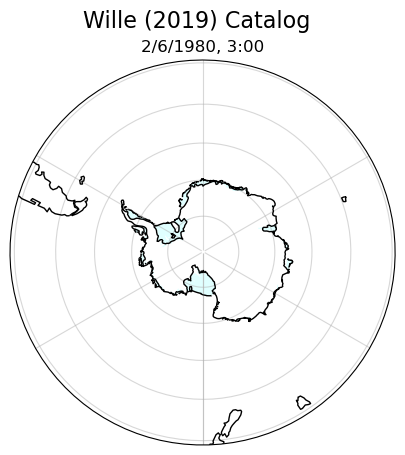

In [31]:
fig, ax = plt.subplots(figsize=(5,5), subplot_kw=dict(projection=ccrs.Stereographic(central_longitude=0., central_latitude=-90.)))
plt_time(0)
fig.suptitle('Wille (2019) Catalog', fontsize=16)

def update_img(i):
    ax.clear()
    plt_time(i)

ani = animation.FuncAnimation(fig, update_img, frames=len(times))

In [32]:
def save_progress(i, n):
    if i%5 == 0: {print(f'Saving frame {i}/{n}')}

ani.save('wille_raw_catalog.mp4', progress_callback=save_progress)

Saving frame 0/33
Saving frame 5/33
Saving frame 10/33
Saving frame 15/33
Saving frame 20/33
Saving frame 25/33
Saving frame 30/33


In [21]:
os.getcwd()

'/home/jovyan/extreme_antarctic_ARs/scripts'

In [33]:
plt_df = cluster_infos_df

unique_clusters = plt_df['cluster'].unique()
color_mapping = {unique_clusters[j]:prism(j/len(unique_clusters)) for j in range(len(unique_clusters)) }

times = np.array(pd.date_range('1980-02-06T03:00:00.000000000', '1980-02-10T03:00:00.000000000', freq='3h'))




def plt_time(j):
    time_pt = times[j]

    if (time_pt == plt_df.time).any():
        dat = plt_df[plt_df['time'] == time_pt]
        n_clusts = dat.shape[0]

        for i in range(n_clusts):
            cluster = dat['cluster'].iloc[i]
            ax.scatter(dat['lons'].iloc[i], dat['lats'].iloc[i], transform=ccrs.PlateCarree(), s=1, color=color_mapping[cluster], label=str(cluster), zorder=30)
            ax.annotate(text=str(cluster), xy=(dat['mean_lon'].iloc[i], dat['mean_lat'].iloc[i]), transform=ccrs.PlateCarree(), zorder=35)
        
        ax.legend()

    #if (time_pt == practice_catalog.time).any():
        # grab time slice from Jonathan's raw AR catalogs
    #    catalog_slice = practice_catalog.sel(time=time_pt)
    #    ax.contour(catalog_slice.lon, catalog_slice.lat, catalog_slice, transform=ccrs.PlateCarree(), zorder=31, linestyles='dotted', colors='black', linewidths=1)
    
    ax.set_extent([-180,180,-90,-39], ccrs.PlateCarree())
    #land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',edgecolor='none',facecolor='white') # 10m, 50m, 110m
    #ax.add_feature(land_50m,linewidth=3)
    ice_shelf_poly = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_polys', '50m',edgecolor='none',facecolor='lightcyan') # 10m, 50m, 110m
    ax.add_feature(ice_shelf_poly,linewidth=3)
    ice_shelf_line = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_lines', '50m',edgecolor='black',facecolor='none') # 10m, 50m, 110m
    ax.add_feature(ice_shelf_line,linewidth=1,zorder=13)
    ax.coastlines(resolution='110m',linewidth=1,zorder=32)

    
    # Map extent 
    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)
    ax.gridlines(alpha=0.5, zorder=33)
    
    time_ts = pd.Timestamp(time_pt)
    ax.set_title(f'{time_ts.month}/{time_ts.day}/{time_ts.year}, {time_ts.hour}:00')

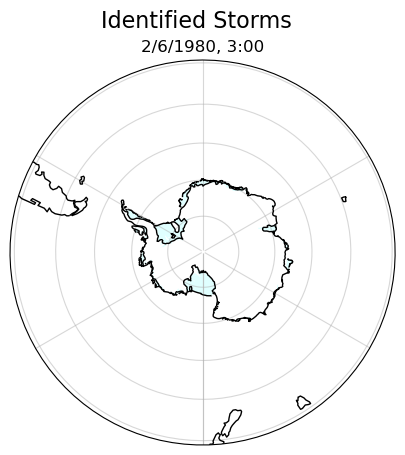

In [34]:
fig, ax = plt.subplots(figsize=(5,5), subplot_kw=dict(projection=ccrs.Stereographic(central_longitude=0., central_latitude=-90.)))
plt_time(0)
fig.suptitle('Identified Storms', fontsize=16)

def update_img(i):
    ax.clear()
    plt_time(i)

ani = animation.FuncAnimation(fig, update_img, frames=len(times))

In [35]:
def save_progress(i, n):
    if i%5 == 0: {print(f'Saving frame {i}/{n}')}

ani.save('identifier_test.mp4', progress_callback=save_progress)

Saving frame 0/33
Saving frame 5/33
Saving frame 10/33
Saving frame 15/33
Saving frame 20/33
Saving frame 25/33
Saving frame 30/33


In [45]:
Video('identifier_test_jonathan.mp4')

### Test Movie

Pick the year 2022 (because that has the big AR associated with the heat wave!) Make another movie down here showcasing the identified ARs to see how good of a job it does on a dataset we didn't use to tune the algorithm. (**TBD**)

### Converting Back to One-Hot Encoded Format

In [5]:
curwd = os.getcwd()
identified_catalog = pd.read_pickle(curwd + '/cluster_infos_1980.pkl')

In [6]:
times = identified_catalog.time.unique()

In [7]:
da_lst = [None]*times.shape[0]
for i in range(times.shape[0]):
    single_df = identified_catalog[identified_catalog.time == times[i]]
    n_storms = single_df.shape[0]
    storm_df = [None]*n_storms

    for j in range(single_df.shape[0]):
        lats = pd.Series(single_df[['cluster', 'lats', 'lons']].lats.iloc[j])
        lons = pd.Series(single_df[['cluster', 'lats', 'lons']].lons.iloc[j])

        points = pd.DataFrame({'lat':lats, 'lon':lons})
        points['cluster'] = single_df['cluster'].iloc[j]
        storm_df[j] = points

    time_df = pd.concat(storm_df, axis=0)
    raster_day = time_df.set_index(['lat', 'lon']).to_xarray()
    da_lst[i] = raster_day

year_da = xr.concat(da_lst, dim='time')
year_da = year_da.assign_coords(time = times)
times = np.array(pd.date_range('1980-01-02T03:00:00.000000000', '1980-12-31T03:00:00.000000000', freq='3h'))
year_da = year_da.reindex(lat=practice_catalog.lat, lon=practice_catalog.lon, time=times)

year_da = year_da.fillna(0)
year_da = year_da.chunk('auto')

In [83]:
full_catalog.sel(time=full_catalog.time.dt.year.isin([1980, 1981, 1982]))

<xarray.Dataset> Size: 2GB
Dimensions:        (time: 8768, lat: 361, lon: 576)
Coordinates:
  * lat            (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 89.0 89.5 90.0
  * lon            (lon) float64 5kB -180.0 -179.4 -178.8 ... 178.1 178.8 179.4
  * time           (time) datetime64[ns] 70kB 1980-01-01 ... 1982-12-31T21:00:00
Data variables:
    ar_binary_tag  (time, lat, lon) int8 2GB dask.array<chunksize=(1, 361, 576), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 1.9.6 (http://mpimet.mpg.de/...
    Conventions:  CF-1.6
    history:      Thu Feb  9 11:32:59 2023: ncks -4 -L 1 temp_MERRA2.ar_tag.W...
    description:  ARTMIP file format (Ullrich)
    NCO:          netCDF Operators version 5.0.0 (Homepage = http://nco.sf.ne...
    CDO:          Climate Data Operators version 1.9.6 (http://mpimet.mpg.de/...

In [2]:
import xarray as xr
import pandas as pd

path = '/scratch/users/butlerj/extreme_antarctic_ars/dataframes/1980_storm_df.csv'
df = pd.read_csv(path)

In [7]:
df

,Unnamed: 0,cluster,lats,lons,rep_lats,rep_lons,mean_lat,mean_lon,time,is_landfalling
0,0,1.0,"[-60.5, -60.5, -60.5, -60.5, -60.5, -60.5, -60...","[-113.75, -113.125, -112.5, -111.875, -111.25,...","[np.float64(-58.0), np.float64(-50.0), np.floa...","[np.float64(-108.125), np.float64(-118.125), n...",-51.449567,-111.333321,1980-01-02 00:00:00,False
1,1,1.0,"[-62.0, -62.0, -62.0, -62.0, -62.0, -62.0, -61...","[-107.5, -106.875, -106.25, -105.625, -105.0, ...","[np.float64(-49.0), np.float64(-48.5), np.floa...","[np.float64(-104.375), np.float64(-111.875), n...",-51.827570,-109.088551,1980-01-02 03:00:00,False
2,2,1.0,"[-63.0, -63.0, -63.0, -63.0, -63.0, -63.0, -63...","[-108.125, -107.5, -106.875, -106.25, -105.625...","[np.float64(-52.5), np.float64(-51.5), np.floa...","[np.float64(-111.25), np.float64(-108.125), np...",-52.516089,-106.680298,1980-01-02 06:00:00,False
3,3,1.0,"[-64.0, -64.0, -64.0, -64.0, -63.5, -63.5, -63...","[-103.75, -103.125, -102.5, -101.875, -106.25,...","[np.float64(-62.5), np.float64(-47.5), np.floa...","[np.float64(-105.625), np.float64(-98.75), np....",-53.360444,-104.424113,1980-01-02 09:00:00,False
4,4,1.0,"[-65.0, -65.0, -65.0, -65.0, -64.5, -64.5, -64...","[-102.5, -101.875, -101.25, -100.625, -103.75,...","[np.float64(-56.0), np.float64(-55.5), np.floa...","[np.float64(-102.5), np.float64(-96.875), np.f...",-54.655259,-102.323422,1980-01-02 12:00:00,False
...,...,...,...,...,...,...,...,...,...,...
1294,1294,185.0,"[-83.5, -83.5, -83.5, -83.5, -83.5, -83.5, -83...","[-68.75, -68.125, -67.5, -66.875, -66.25, -65....","[np.float64(-83.0), np.float64(-81.0), np.floa...","[np.float64(-59.375), np.float64(-61.25), np.f...",-79.481929,-58.724285,1980-12-31 18:00:00,True
1295,1295,185.0,"[-74.5, -74.5, -74.5, -74.5, -74.5, -74.5, -74...","[-100.625, -100.0, -99.375, -98.75, -98.125, -...","[np.float64(-71.0), np.float64(-74.0), np.floa...","[np.float64(-101.875), np.float64(-85.625), np...",-70.670942,-92.989485,1980-12-31 18:00:00,True
1296,1296,185.0,"[-66.0, -66.0, -66.0, -66.0, -65.5, -65.5, -65...","[-143.75, -143.125, -142.5, -141.875, -143.75,...","[np.float64(-64.0), np.float64(-61.0), np.floa...","[np.float64(-139.375), np.float64(-138.125), n...",-63.097034,-139.630187,1980-12-31 18:00:00,False
1297,1297,185.0,"[-59.0, -58.5, -58.5, -58.5, -58.5, -58.5, -58...","[-108.125, -115.625, -115.0, -111.875, -111.25...","[np.float64(-54.5), np.float64(-55.0), np.floa...","[np.float64(-116.25), np.float64(-113.75), np....",-55.781984,-116.480760,1980-12-31 18:00:00,False


In [5]:
path = '/scratch/users/butlerj/extreme_antarctic_ars/datarrays/1980_storm_da.nc'
da = xr.open_dataset(path)

In [6]:
da

<xarray.Dataset> Size: 320MB
Dimensions:  (lat: 95, lon: 576, time: 2928)
Coordinates:
  * lat      (lat) float64 760B -86.0 -85.5 -85.0 -84.5 ... -40.0 -39.5 -39.0
  * lon      (lon) float64 5kB -180.0 -179.4 -178.8 -178.1 ... 178.1 178.8 179.4
  * time     (time) datetime64[ns] 23kB 1980-01-01 ... 1980-12-31T21:00:00
Data variables:
    cluster  (time, lat, lon) int16 320MB ...